# Bibliotecas




In [55]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import random
import colorsys
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap


# Definición de funciones


## Funciones generadoras de colores


In [56]:
#Colores aleatorios no tan aleatorios ("n-complementarios")
def c(N):
  H0 = random.randint(0,360)
  H = [H0/360]                      #Hue (normalizado)
  s = np.random.uniform(0.2,1,N)    #Saturation
  v = np.random.uniform(0.2,1,N)    #Value

  if N != 1:
    for i in range(1,N):

      H.append(
          np.mod(H0+360*i/N , 360)/360
          )

      color_list=[
          colorsys.hsv_to_rgb(H[x],s[x],v[x]) for x in range(len(H))
          ]
  else: #solo por si queremos un color
    color_list=[
        colorsys.hsv_to_rgb(H[0],s[0],v[0])
        ]


  return(list(color_list))

In [57]:
#Monocromatico

#Esta funcion devuelve un color aleatorio fuerte para despues ir bajando el brillo
def c_m(N):
  H0 = random.randint(0,360)
  H = [H0/360]                      #Hue (normalizado)
  s = np.random.uniform(0.9,1,N)    #Saturation
  v = np.random.uniform(0.9,1,N)    #Value

  if N != 1:
    for i in range(1,N):

      H.append(
          np.mod(H0+360*i/N , 360)/360
          )

      color_list=[
          colorsys.hsv_to_rgb(H[x],s[x],v[x]) for x in range(len(H))
          ]
  else: #solo por si queremos un color
    color_list=[
        colorsys.hsv_to_rgb(H[0],s[0],v[0])
        ]


  return(list(color_list))

def monochromatic(N):
  C = np.array(c_m(1))
  C = [colorsys.rgb_to_hsv(
      C[0][0],C[0][1],C[0][2])
      ]

  for i in range(N-1):

    C.append(
        (C[0][0],C[0][1]*(N-i-1)/N,C[0][2]*(N-i-1)/N)
    )

  color_list=[
          colorsys.hsv_to_rgb(C[x][0],C[x][1],C[x][2]) for x in range(len(C))
          ]

  return(color_list)

"""
Genera N colores en una ruta: Blanco -> color1 -> color2 -> Negro.
color1 y color2 son complementarios aleatorios.
La cantidad total de colores es exactamente N.
"""
def color_range(N):

    if N < 2:
        return c_m(N)

    # 1. Calcular tamaños de las secciones
    # N_side para degradados Blanco->C1 y C2->Negro (min 1)
    # N_interp para ruta complementaria lineal C1->C2 (min 2)
    N_side = max(1, N // 4)
    N_interp = max(2, N - 2 * N_side)

    # Asegurar que el total sea exactamente N
    # (Casos de borde para N pequeños)
    if N - 2 * N_side != N_interp:
        N_interp = N - 2 * N_side

    # Si N es tan pequeño que N_interp es inválido (N<4),
    # revertimos a una ruta complementaria simple para mantener funcionalidad
    if N_interp < 2:
        extremos = c_m(2)
        color1 = np.array(extremos[0])
        color2 = np.array(extremos[1])
        return [tuple(color1 * (1 - i/(N-1)) + color2 * (i/(N-1))) for i in range(N)]

    # 2. Obtener complementarios extremos (puntos de anclaje)
    extremos = c_m(2)
    color1 = np.array(extremos[0]) # C1
    color2 = np.array(extremos[1]) # C2
    White = np.array((1, 1, 1))
    Black = np.array((0, 0, 0))

    paleta = []

    # Degradado Blanco ->  color1 (excluye color1)
    for i in range(N_side):
        t = i / N_side
        paleta.append(tuple(White * (1 - t) + color1 * t))

    # Ruta color1 -> color2 (incluye ambos)
    for i in range(N_interp):
        t = i / (N_interp - 1)
        paleta.append(tuple(color1 * (1 - t) + color2 * t))

    # color2 -> hacia Negro (excluye color2)
    for i in range(1, N_side + 1):
        t = i / N_side # t va de 1/N_side a 1.0
        paleta.append(tuple(color2 * (1 - t) + Black * t))

    return paleta[::-1]

def color_range_without_grading(N):
    if N < 2:
        return c_m(N)

    extremos = c_m(2)
    color1 = np.array(extremos[0])
    color2 = np.array(extremos[1])

    color_list = []

    for i in range(N):
        # 't' es el porcentaje de avance entre el color 1 y el color 2 (va de 0.0 a 1.0)
        t = i / (N - 1)

        color_intermedio = color1 * (1 - t) + color2 * t
        color_list.append(tuple(color_intermedio))

    return color_list

In [58]:
#Triada
def c_reduced_range(N):
  C = c(1)
  C = [colorsys.rgb_to_hsv(
      C[x][0],C[x][1],C[x][2]) for x in range(len(C))
      ]

  s = np.random.uniform(0.8, 0.9)
  for i in range(N-1):
    r = np.random.uniform(0, 0.2)

    C.append(
        (C[i][0]*(1+(-1)**i*r),C[i][1],C[i][2]*s)
    )

  color_list=[
          colorsys.hsv_to_rgb(C[x][0],C[x][1],C[x][2]) for x in range(len(C))
          ]

  return(color_list)

In [59]:
#Paleta
def paleta(C):

  C.append((0,0,0))

  plt.figure()
  nombre_color = []

  for i in range(len(C)-1):
    square = plt.Rectangle((i,0),1,1,fc=C[i])
    plt.gca().add_patch(square);

    nombre_color.append(
        matplotlib.colors.to_hex(
            [C[i][x] for x in range(3)]
          )
        )

    plt.text(0.4+i,-0.15,nombre_color[i],fontsize=17,weight='bold')

  plt.xlim(0,len(C)-1);
  plt.subplots_adjust(bottom= 1, top = 1.5, left=1, right=4.5);
  plt.axis('off');
  print(nombre_color)

  C.remove((0,0,0))

## Funciones de Test

In [60]:
def test_palette(color_generator_function, n_colors, n_palettes = 3):
    """
    Llama N veces a la función paleta.

    Parámetros:
    - colors: Puede ser una lista de colores o una lista de listas de colores.
    - N: Cantidad de veces que se ejecutará la visualización.
    """
    for i in range(n_palettes):
        paleta(color_generator_function(n_colors))

In [61]:
def psi_310(x, z):
    """Función auxiliar para el orbital 2D del Hidrógeno (n=3, l=1, m=0)."""
    r = np.sqrt(x**2 + z**2)
    r = np.where(r == 0, 1e-10, r)
    return ((6*r - r**2) * np.exp(-r/3)) * (z / r)


def test_grafico(color_palette, heat_map=False):
    """
    - Fila 0: SIEMPRE la paleta de colores (ocupa ambas columnas).
    - Fila 1: Líneas y Scatter.
    - Fila 2 (Si heat_map=True): Hidrógeno 2D y Gausianas 3D.
    """
    n_curves = len(color_palette)
    if n_curves == 0: return []

    hacer_scatter = n_curves <= 20
    if not hacer_scatter:
        print(f"⚠️ {n_curves} colores (> 20). Se omitirá el scatter.")

    # ==========================================
    # Configuración Condicional del Layout
    # ==========================================

    if heat_map:
        # Layout de 3 filas x 2 columnas
        fig = plt.figure(figsize=(12, 11))
        gs = gridspec.GridSpec(3, 2, height_ratios=[1, 4, 4])

        ax_palette = fig.add_subplot(gs[0, :])
        ax_lines = fig.add_subplot(gs[1, 0])
        ax_scatter = fig.add_subplot(gs[1, 1])
        ax_heat = fig.add_subplot(gs[2, 0])
        ax_3d = fig.add_subplot(gs[2, 1], projection='3d')

    else:
        # Layout de 2 filas x 2 columnas
        fig = plt.figure(figsize=(12, 6.5))
        gs = gridspec.GridSpec(2, 2, height_ratios=[1, 4])

        ax_palette = fig.add_subplot(gs[0, :])
        ax_lines = fig.add_subplot(gs[1, 0])
        ax_scatter = fig.add_subplot(gs[1, 1])


    # ==========================================
    # Gráfico de la Paleta de Colores
    # ==========================================
    nombre_color = []

    for i, color in enumerate(color_palette):
        hex_code = matplotlib.colors.to_hex(color)
        nombre_color.append(hex_code)

        square = plt.Rectangle((i, 0), 1, 1, fc=color)
        ax_palette.add_patch(square)

        font_s = 15 if n_curves <= 12 else 9
        rot = 0 if n_curves <= 12 else 45

        ax_palette.text(i + 0.5, -0.2, hex_code, fontsize=font_s, weight='bold',
                        ha='center', va='top', rotation=rot)

    ax_palette.set_xlim(0, n_curves)
    ax_palette.set_ylim(0, 1)
    ax_palette.axis('off')
    ax_palette.set_title("Paleta de Colores Extraída", pad=15, fontweight='bold')


    markers = ['o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X']
    x_line = np.linspace(0, 5, 500)
    x_scatter = np.linspace(0.5, 4.5, len(markers))

    # ==========================================
    # Gráfico de Líneas
    # ==========================================
    for idx, color in enumerate(color_palette):
        y_line = (0.5 * (idx + 1)) * (2 / np.pi) * np.arctan(x_line)
        ax_lines.plot(x_line, y_line, color=color, linewidth=2.5)
    ax_lines.set(title='Líneas', xlabel='X', ylabel='Y', xlim=(0, 5))
    ax_lines.grid(True, ls="--", alpha=0.5)

    # ==========================================
    # Gráfico Scatter
    # ==========================================
    if hacer_scatter:
        ALTURA_BASE = 1
        SEPARACION_VERTICAL = 5.0

        for idx, color in enumerate(color_palette):
            line_height = ALTURA_BASE + (idx * SEPARACION_VERTICAL)
            y_scatter = np.full_like(x_scatter, line_height)
            ax_scatter.plot(x_scatter, y_scatter, color=color, alpha=0.3, zorder=1, linewidth=1.5)

            for j, m in enumerate(markers):
                ax_scatter.scatter(x_scatter[j], y_scatter[j], color=color,
                                    edgecolors='black', marker=m, s=80, zorder=3, alpha=0.9)

        max_height_needed = ALTURA_BASE + (n_curves * SEPARACION_VERTICAL)
        ax_scatter.set_ylim(0 - SEPARACION_VERTICAL, max_height_needed + SEPARACION_VERTICAL/2)
        ax_scatter.set(title='Scatter', xlabel='X', ylabel='Y', xlim=(0, 5.5))
        ax_scatter.grid(True, ls="--", alpha=0.5)

    else:
        ax_scatter.text(0.5, 0.5, "Scatter omitido\n(> 20 colores)", ha='center', va='center', fontsize=12)
        ax_scatter.set(xticks=[], yticks=[])

    # ==========================================
    # --- Gráficos Condicionales del Layout 3x2 ---
    # ==========================================
    if heat_map:
        # 3. Hidrógeno 2D
        cmap_list = [np.array(matplotlib.colors.to_rgb(c)) for c in color_palette]
        cmap_per = LinearSegmentedColormap.from_list("grad_with_ends", cmap_list)

        x = z = np.linspace(-25, 25, 1000)
        X, Z = np.meshgrid(x, z)
        prob_visual = np.abs(psi_310(X, Z))

        im = ax_heat.imshow(prob_visual, extent=[-25, 25, -25, 25],
                            cmap=cmap_per, origin='lower')
        fig.colorbar(im, ax=ax_heat)
        ax_heat.set(title="Mapa de calor", xticks=[], yticks=[])

        # 4. Gausianas 3D
        x_g = y_g = np.linspace(-4, 4, 150)
        Xg, Yg = np.meshgrid(x_g, y_g)
        Z1 = np.exp(-((Xg + 1)**2 + (Yg + 0.5)**2) / 1.5)
        Z2 = np.exp(-((Xg - 1.5)**2 + (Yg - 0.5)**2) / 2.0)
        Zg = Z1 + Z2

        surf = ax_3d.plot_surface(Xg, Yg, Zg, cmap=cmap_per, edgecolor='none', alpha=0.9, zorder=1)
        ax_3d.contourf(Xg, Yg, Zg, zdir='z', offset=0, cmap=cmap_per, alpha=0.3)
        ax_3d.contourf(Xg, Yg, Zg, zdir='y', offset=-4, cmap=cmap_per, alpha=0.3)
        ax_3d.contourf(Xg, Yg, Zg, zdir='x', offset=-4, cmap=cmap_per, alpha=0.3)

        ax_3d.set(title="Superficie 3D", xlabel='X', ylabel='Y', zlabel='Z')
        fig.colorbar(surf, ax=ax_3d, label='Densidad', pad=0.1)
        ax_3d.view_init(elev=35, azim=45)
        ax_3d.set_zlim(0, Zg.max())


    plt.tight_layout()
    plt.show()

    print("Lista de colores en codigo HEX")
    print(nombre_color)



# Generación de paletas de colores


<font face="monospace" size="4" color="#000000">
Con todos los codigos generados se pueden utilizar dos funciones para lograr probar las distintas paletas de colores.
</font>

<br><br>

<font face="monospace" size="4">
  <font color="#c45400">test_palette</font><font color="#b07d00">(</font><font color="#0066cc">color_generator_function</font>, <font color="#0066cc">n_colors</font>, <font color="#0066cc">n_palettes</font> <font color="#000000">=</font> <font color="#0033b3">3</font><font color="#b07d00">)</font>
</font>


<font color="#000000" face="monospace" size="4">
Permite generar una cantidad deseada de paletas con 
<font color="#0066cc">n_palettes</font> 
(por defecto son 3) y cada paleta cuenta con una cantidad de colores designada por el usuario con
<font color="#0066cc">n_colors</font>. 
Para decidir de que manera queremos generar los colores tenemos que usar
<font color="#0066cc">color_generator_function</font>. 
Las opciones para esta son:
</font>

<ul>
  <li><font face="monospace" size="4" color="#000000"><font color="#c45400">c</font> : Genera <font color="#0066cc">n_colors</font> colores complementarios. Para hacer esto se designa aleatoriamente el primer color de manera al azar y el resto se toman de manera que todos sean complementarios formando un poligono sobre el circulo cromático. Para ver más información sobre esto puede ver el siguiente <a href="https://stackoverflow.com/questions/37055755/computing-complementary-triadic-tetradic-and-analagous-colors" style="color: #0000EE;">link</a>.</font></li>

  <li><font face="monospace" size="4" color="#000000"><font color="#c45400">monochromatic</font> : Se generan <font color="#0066cc">n_colors</font> colores a partir de un unico color aleatorio. Se utiliza el codigo HSV normalizado (valores de 0 a 1) para selecciona de manera al azar un color con un valor de Value (V) cercano a 1. Una vez elegido, el resto de colores se generan disminuyendo este valor de Value de manera escalonada.<br>Para que la paleta de colores se vea "de manera continua" se recomienda tomar un numero alto de <font color="#0066cc">n_colors</font> (por ej. 100).</font></li>

  <li><font face="monospace" size="4" color="#000000"><font color="#c45400">color_range_without_grading</font> : Se generan <font color="#0066cc">n_colors</font> que se encuentren en el camino entre dos colores complementarios. Para generarlos se toma el circulo cromatico, se elije un unico color con un valor de Value alto (este es el punto de inicio) y su complementario (el punto final). Una vez seleccionados los dos puntos en el circulo se traza una linea para interpolarlos y se toman los puntos intermedios de manera escalonada para obtener la gama de colores entera.</font></li>

  <li><font face="monospace" size="4" color="#000000"><font color="#c45400">color_range</font> : Su funcionamiento es similar a <font color="#0066cc">color_range_without_grading</font> con la diferencia que esta funcion hace una modificacion en las colas del array. Comienza con el color negro y luego se generan colores hasta llegar al primer color generado de manera aleatoria. luego se produce el mismo procedimiento que la funcion anterior hasta llegar al segundo color. Finalmente pasamos de este segundo color al blanco de manera escalonada. el camino realizado es el siguiente:</font></li>
</ul>

<center>
  <font face="monospace" size="4" color="#000000"><b>Negro &rarr; color1 &rarr; color2 &rarr; Blanco</b></font>
</center>

<br>
<font face="monospace" size="4" color="#000000">Esta función es ideal para la realización de mapas de calor.</font>

<ul>
  <li><font face="monospace" size="4" color="#000000"><font color="#c45400">c_reduced_range</font> : Se generan <font color="#0066cc">n_colors</font> a partir de un color generado de manera aleatoria. El resto de colores se generan en un entorno cercano de este color. Suele ser ideal para generar una triada (<font color="#0066cc">n_colors</font> = <font color="#0066cc">3</font>) o algun conjunto reducido de colores cercanos en el circulo cromático.</font></li>
</ul>

<hr>

<font face="monospace" size="4">
  <font color="#c45400">test_grafico</font><font color="#b07d00">(</font><font color="#0066cc">color_palette</font>, <font color="#0066cc">heat_map</font> <font color="#000000">=</font> <font color="#0033b3">False</font><font color="#b07d00">)</font>
</font>



<font face="monospace" size="4" color="#000000">
Creamos un conjunto de graficos para comprobar como se veria nuestra paleta de colores en distintas situaciones. Por defecto (<font color="#0066cc">heat_map</font> = <font color="#0033b3">False</font>) se generan dos graficos ademas donde veremos como se ve la paleta sobre distintas lineas y por otro lado se generan todos los markers que ofrece Python con los distintos colores generados.
<br><br>
En el caso en el que (<font color="#0066cc">heat_map</font> = <font color="#0033b3">True</font>) vamos a generar dos graficos extra en el que veremos como se muestra nuestra paleta generada cuando trabajamos con mapas de calor. Esto es ideal cuando trabajamos con paletas monocromáticas o que toman un rango de colores amplio.
<br><br>
Para generar los colores usamos el atributo <font color="#0066cc">color_palette</font> en el cual tendremos que pasarle el array con la paleta de colores, esto se puede simplificar usando las funciones que vimos anteriormente:
</font>

<br><br>

<center>
  <font face="monospace" size="4">
    <font color="#c45400">c</font><font color="#b07d00">(</font><font color="#0066cc">N</font><font color="#b07d00">)</font>,
    <font color="#c45400">monochromatic</font><font color="#b07d00">(</font><font color="#0066cc">N</font><font color="#b07d00">)</font>,
    <font color="#c45400">color_range_without_grading</font><font color="#b07d00">(</font><font color="#0066cc">N</font><font color="#b07d00">)</font>,
    <font color="#c45400">color_range</font><font color="#b07d00">(</font><font color="#0066cc">N</font><font color="#b07d00">)</font> y 
    <font color="#c45400">c_reduced_range</font><font color="#b07d00">(</font><font color="#0066cc">N</font><font color="#b07d00">)</font>
  </font>
</center>

<br>
<font face="monospace" size="4" color="#000000">Donde <font color="#0066cc">N</font> es la cantidad de colores que vamos a generar con la función designada.</font>

['#0b840f', '#9bc5d2', '#69409f', '#810432', '#615209']
['#d0912a', '#307321', '#1c8384', '#3e21aa', '#9e4077']
['#95a178', '#50d28f', '#879cca', '#370a3d', '#76130a']


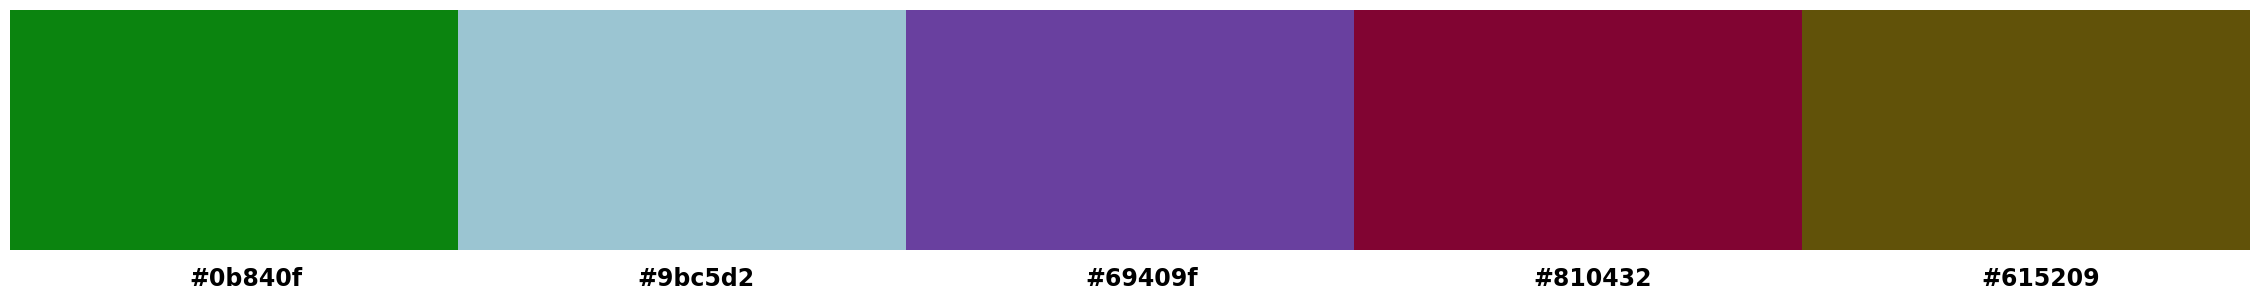

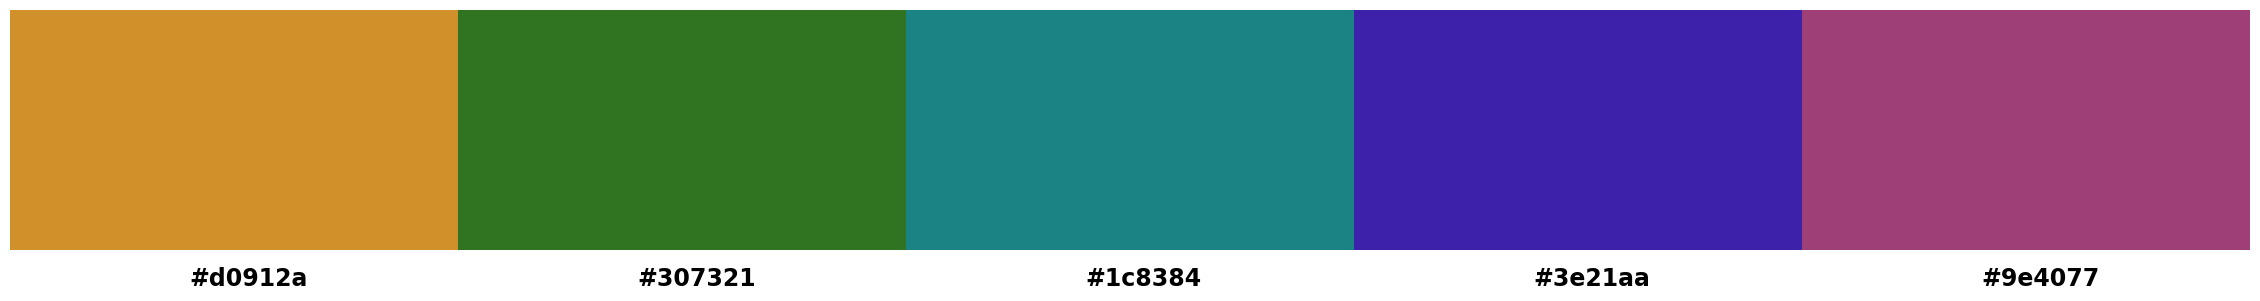

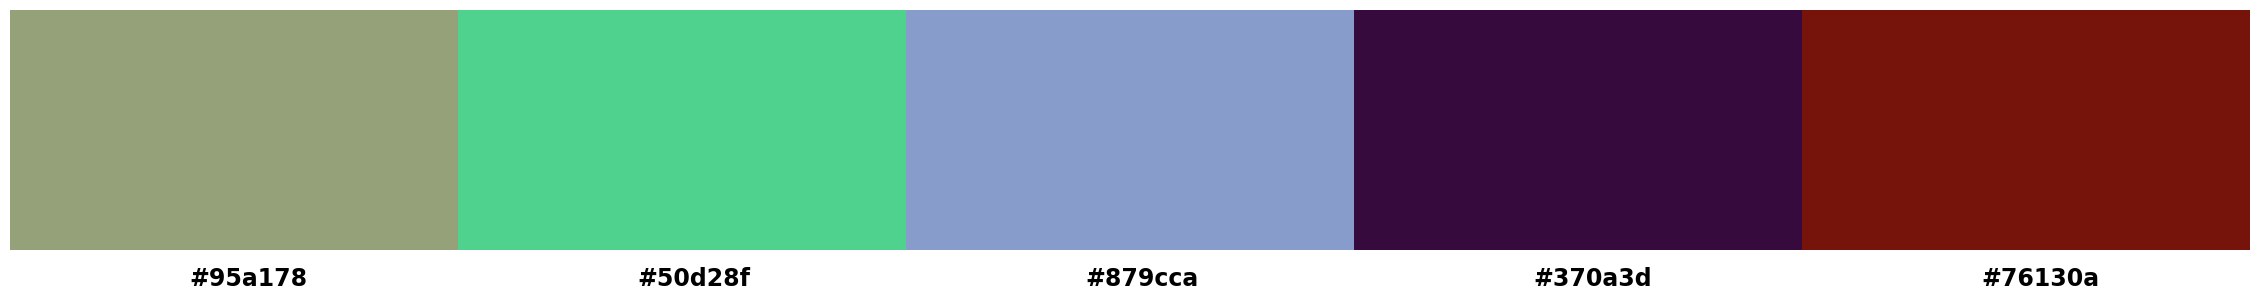

In [62]:
test_palette(c,5)

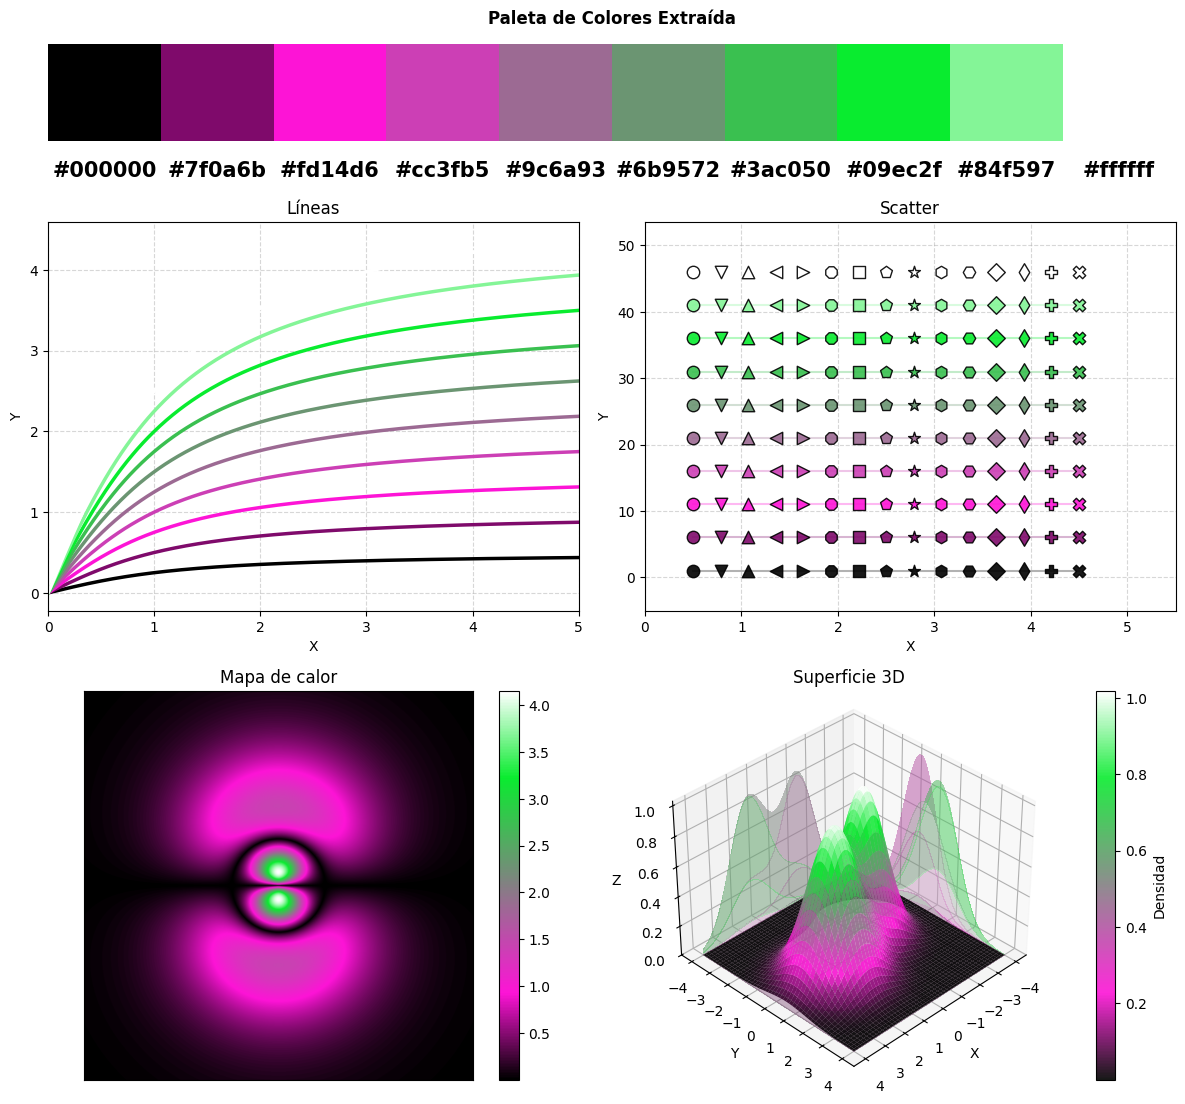

Lista de colores en codigo HEX
['#000000', '#7f0a6b', '#fd14d6', '#cc3fb5', '#9c6a93', '#6b9572', '#3ac050', '#09ec2f', '#84f597', '#ffffff']


In [63]:
test_grafico(color_range(10), heat_map=True)